In [1]:
# 1. Install dependencies
!pip install grad-cam -q

# 2. Download the dataset (requires Kaggle API key)
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip chest-xray-pneumonia.zip -d .
import os
import copy
import time
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# pytorch-grad-cam library (pip install grad-cam)
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

print("All libraries imported successfully.")
print(f"PyTorch version : {torch.__version__}")

Streaming output truncated to the last 5000 lines.
  inflating: ./chest_xray/train/NORMAL/IM-0437-0001-0001.jpeg  
  inflating: ./chest_xray/train/NORMAL/IM-0437-0001-0002.jpeg  
  inflating: ./chest_xray/train/NORMAL/IM-0437-0001.jpeg  
  inflating: ./chest_xray/train/NORMAL/IM-0438-0001.jpeg  
  inflating: ./chest_xray/train/NORMAL/IM-0439-0001-0001.jpeg  
  inflating: ./chest_xray/train/NORMAL/IM-0439-0001-0002.jpeg  
  inflating: ./chest_xray/train/NORMAL/IM-0439-0001.jpeg  
  inflating: ./chest_xray/train/NORMAL/IM-0440-0001.jpeg  
  inflating: ./chest_xray/train/NORMAL/IM-0441-0001.jpeg  
  inflating: ./chest_xray/train/NORMAL/IM-0442-0001.jpeg  
  inflating: ./chest_xray/train/NORMAL/IM-0444-0001.jpeg  
  inflating: ./chest_xray/train/NORMAL/IM-0445-0001.jpeg  
  inflating: ./chest_xray/train/NORMAL/IM-0446-0001.jpeg  
  inflating: ./chest_xray/train/NORMAL/IM-0447-0001.jpeg  
  inflating: ./chest_xray/train/NORMAL/IM-0448-0001.jpeg  
  inflating: ./chest_xray/train/NORMAL/IM-04

In [2]:
# ---- Hyper-parameters (change here only) ----
DATA_DIR        = "chest_xray"          # root folder of the dataset
IMG_SIZE        = 224                   # EfficientNet standard input
BATCH_SIZE      = 32
NUM_CLASSES     = 2                     # NORMAL vs PNEUMONIA
NUM_EPOCHS_HEAD = 10                    # epochs for classifier head only
NUM_EPOCHS_FINE = 15                    # additional epochs for fine-tuning
LR_HEAD         = 1e-3                  # learning rate — head training
LR_FINE         = 1e-4                  # learning rate — fine-tuning
PATIENCE        = 5                     # early-stopping patience
BEST_MODEL_PATH = "best_model.pth"      # where to save best weights
SEED            = 42

# ---- Reproducibility ----
torch.manual_seed(SEED)
np.random.seed(SEED)

# ---- Use GPU if available ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Using device: cuda
GPU: Tesla T4


In [3]:
# Training transforms  — augmentation to prevent overfitting
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE + 20, IMG_SIZE + 20)),  # slight oversize then crop
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    # ImageNet mean/std — EfficientNet was pretrained on ImageNet
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

# Validation & Test transforms — no augmentation, just resize + normalize
val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

print("Transforms defined.")

Transforms defined.


In [4]:
train_dataset=datasets.ImageFolder(root=os.path.join(DATA_DIR,"train"),transform=train_transforms,)
test_dataset=datasets.ImageFolder(root=os.path.join(DATA_DIR,"test"),transform=val_test_transforms,)
val_dataset=datasets.ImageFolder(root=os.path.join(DATA_DIR,"val"),transform=val_test_transforms,)

train_loader =DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True,num_workers=2,pin_memory=True)
test_loader=DataLoader(test_dataset,batch_size=BATCH_SIZE,shuffle=False,num_workers=2,pin_memory=True)
val_loader=DataLoader(val_dataset,batch_size=BATCH_SIZE,shuffle=False,num_workers=2,pin_memory=True)


In [5]:
Class_Names=train_dataset.classes
print(Class_Names)
print(f"Train samples: {len(train_dataset)}")
print(f"Val   samples: {len(val_dataset)}")
print(f"Test  samples: {len(test_dataset)}")

print("\nDataLoaders ready.")

['NORMAL', 'PNEUMONIA']
Train samples: 5216
Val   samples: 16
Test  samples: 624

DataLoaders ready.


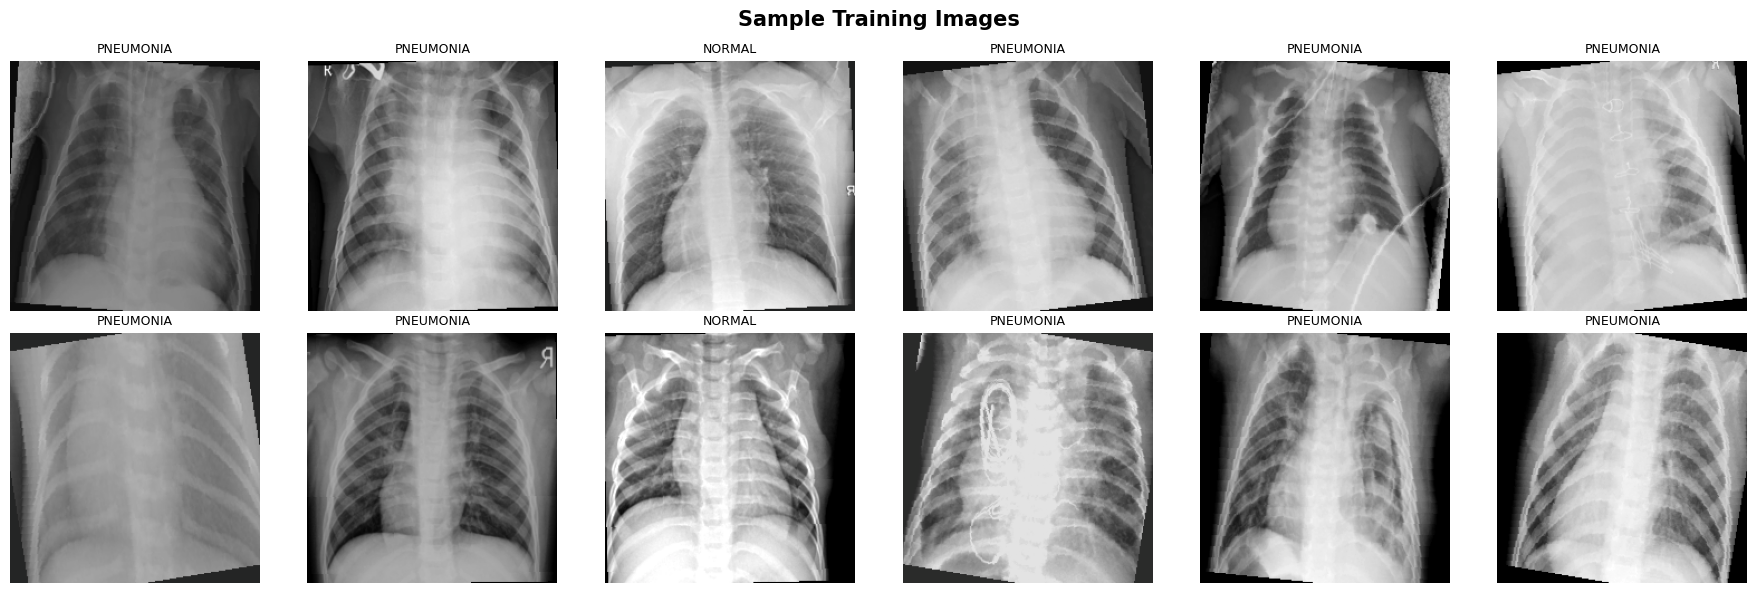

Sample images saved.


In [6]:
# Un-normalise for display
INV_MEAN = torch.tensor([0.485, 0.456, 0.406])
INV_STD  = torch.tensor([0.229, 0.224, 0.225])

sample_images, sample_labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
fig.suptitle("Sample Training Images", fontsize=15, fontweight="bold")

for i, ax in enumerate(axes.flat):
    if i >= len(sample_images):
        break
    img = sample_images[i].cpu().clone()
    img = img * INV_STD[:, None, None] + INV_MEAN[:, None, None]
    img = img.permute(1, 2, 0).clamp(0, 1).numpy()
    ax.imshow(img)
    ax.set_title(Class_Names[sample_labels[i].item()], fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.savefig("sample_images.png", dpi=100, bbox_inches="tight")
plt.show()
print("Sample images saved.")

In [7]:
model=models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
for param in model.parameters():
    param.requires_grad = False



Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 95.9MB/s]


In [8]:
model.classifier = nn.Sequential(
    nn.Dropout(p=0.4, inplace=True),
    nn.Linear(model.classifier[1].in_features, 256),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(256, NUM_CLASSES),          # output: 2 logits
)
model = model.to(device)


In [9]:
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel        : EfficientNet-B0")
print(f"Total params : {total_params:,}")
print(f"Trainable    : {trainable_params:,}  (head only — base frozen)")


Model        : EfficientNet-B0
Total params : 4,335,998
Trainable    : 328,450  (head only — base frozen)


In [10]:

# CrossEntropyLoss is standard for multi-class (works for binary too)
criterion = nn.CrossEntropyLoss()

# Only optimise the classifier head parameters
optimizer_head = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_HEAD,
)

# Reduce LR if val loss doesn't improve for 3 epochs
scheduler_head = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_head, mode="min", factor=0.5, patience=3,
)

print("\nLoss & optimizer ready for HEAD training.")


Loss & optimizer ready for HEAD training.


In [11]:

# History containers
head_train_losses, head_val_losses   = [], []
head_train_accs,   head_val_accs     = [], []

# Early stopping state
best_val_loss_head = float("inf")
patience_counter_head = 0
best_model_weights = copy.deepcopy(model.state_dict())  # initial snapshot

print("\n" + "="*60)
print("PHASE 1 — Training classifier head (base frozen)")
print("="*60)

for epoch in range(1, NUM_EPOCHS_HEAD + 1):
    epoch_start = time.time()

    # ── Training loop ──
    model.train()
    running_loss_train = 0.0
    correct_train      = 0
    total_train        = 0

    for images, labels in train_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer_head.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer_head.step()

        running_loss_train += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct_train += (preds == labels).sum().item()
        total_train   += labels.size(0)

    train_loss = running_loss_train / total_train
    train_acc  = correct_train      / total_train

    # ── Validation loop ──
    model.eval()
    running_loss_val = 0.0
    correct_val      = 0
    total_val        = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            running_loss_val += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct_val += (preds == labels).sum().item()
            total_val   += labels.size(0)

    val_loss = running_loss_val / total_val
    val_acc  = correct_val      / total_val

    # ── Store history ──
    head_train_losses.append(train_loss)
    head_val_losses.append(val_loss)
    head_train_accs.append(train_acc)
    head_val_accs.append(val_acc)

    # ── LR scheduler step ──
    scheduler_head.step(val_loss)

    # ── Early stopping check ──
    if val_loss < best_val_loss_head:
        best_val_loss_head = val_loss
        patience_counter_head = 0
        best_model_weights = copy.deepcopy(model.state_dict())
        torch.save(best_model_weights, BEST_MODEL_PATH)
        saved_flag = " ✓ saved"
    else:
        patience_counter_head += 1
        saved_flag = ""

    elapsed = time.time() - epoch_start
    print(
        f"Epoch [{epoch:02d}/{NUM_EPOCHS_HEAD}] "
        f"| Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} "
        f"| Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f} "
        f"| Time: {elapsed:.1f}s{saved_flag}"
    )

    if patience_counter_head >= PATIENCE:
        print(f"\n>> Early stopping triggered at epoch {epoch} (head phase).")
        break

print("\nPhase 1 training complete.")



PHASE 1 — Training classifier head (base frozen)
Epoch [01/10] | Train Loss: 0.2610  Acc: 0.8919 | Val Loss: 0.4087  Acc: 0.8125 | Time: 106.8s ✓ saved
Epoch [02/10] | Train Loss: 0.2104  Acc: 0.9155 | Val Loss: 0.3309  Acc: 0.8125 | Time: 91.0s ✓ saved
Epoch [03/10] | Train Loss: 0.1939  Acc: 0.9208 | Val Loss: 0.4483  Acc: 0.8750 | Time: 89.4s
Epoch [04/10] | Train Loss: 0.1848  Acc: 0.9266 | Val Loss: 0.3405  Acc: 0.8750 | Time: 89.4s
Epoch [05/10] | Train Loss: 0.1769  Acc: 0.9314 | Val Loss: 0.2961  Acc: 0.8750 | Time: 89.4s ✓ saved
Epoch [06/10] | Train Loss: 0.1797  Acc: 0.9275 | Val Loss: 0.3061  Acc: 0.8750 | Time: 91.3s
Epoch [07/10] | Train Loss: 0.1706  Acc: 0.9294 | Val Loss: 0.4346  Acc: 0.8750 | Time: 89.7s
Epoch [08/10] | Train Loss: 0.1685  Acc: 0.9342 | Val Loss: 0.2794  Acc: 0.8750 | Time: 88.5s ✓ saved
Epoch [09/10] | Train Loss: 0.1720  Acc: 0.9333 | Val Loss: 0.3251  Acc: 0.8750 | Time: 90.0s
Epoch [10/10] | Train Loss: 0.1614  Acc: 0.9348 | Val Loss: 0.3192  Acc

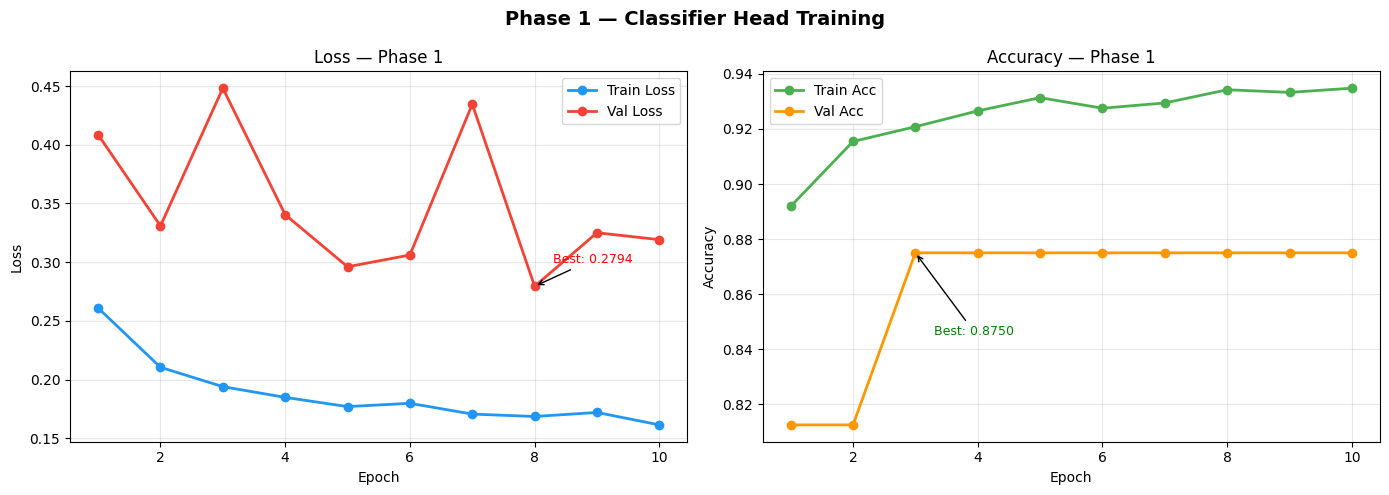


── Phase 1 Summary ──────────────────────────────────────
Epoch    Train Loss     Val Loss       Train Acc      Val Acc
────────────────────────────────────────────────────────────
1        0.2610         0.4087         0.8919         0.8125
2        0.2104         0.3309         0.9155         0.8125
3        0.1939         0.4483         0.9208         0.8750
4        0.1848         0.3405         0.9266         0.8750
5        0.1769         0.2961         0.9314         0.8750
6        0.1797         0.3061         0.9275         0.8750
7        0.1706         0.4346         0.9294         0.8750
8        0.1685         0.2794         0.9342         0.8750 ✓
9        0.1720         0.3251         0.9333         0.8750
10       0.1614         0.3192         0.9348         0.8750
────────────────────────────────────────────────────────────
Best Val Loss : 0.2794  (Epoch 8)
Best Val Acc  : 0.8750  (Epoch 3)


In [12]:
# ──────────────────────────────────────────────────────────────
# PLOT — Phase 1 Training Curves (Head Only)
# ──────────────────────────────────────────────────────────────

epochs_head = list(range(1, len(head_train_losses) + 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Phase 1 — Classifier Head Training", fontsize=14, fontweight="bold")

# ---- Loss ----
ax = axes[0]
ax.plot(epochs_head, head_train_losses, label="Train Loss", color="#2196F3", linewidth=2, marker="o")
ax.plot(epochs_head, head_val_losses,   label="Val Loss",   color="#F44336", linewidth=2, marker="o")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Loss — Phase 1")
ax.legend()
ax.grid(alpha=0.3)

# annotate best val loss
best_epoch = head_val_losses.index(min(head_val_losses)) + 1
best_loss  = min(head_val_losses)
ax.annotate(f"Best: {best_loss:.4f}",
            xy=(best_epoch, best_loss),
            xytext=(best_epoch + 0.3, best_loss + 0.02),
            arrowprops=dict(arrowstyle="->", color="black"),
            fontsize=9, color="red")

# ---- Accuracy ----
ax = axes[1]
ax.plot(epochs_head, head_train_accs, label="Train Acc", color="#4CAF50", linewidth=2, marker="o")
ax.plot(epochs_head, head_val_accs,   label="Val Acc",   color="#FF9800", linewidth=2, marker="o")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy — Phase 1")
ax.legend()
ax.grid(alpha=0.3)

# annotate best val acc
best_acc_epoch = head_val_accs.index(max(head_val_accs)) + 1
best_acc       = max(head_val_accs)
ax.annotate(f"Best: {best_acc:.4f}",
            xy=(best_acc_epoch, best_acc),
            xytext=(best_acc_epoch + 0.3, best_acc - 0.03),
            arrowprops=dict(arrowstyle="->", color="black"),
            fontsize=9, color="green")

plt.tight_layout()
plt.savefig("phase1_curves.png", dpi=120, bbox_inches="tight")
plt.show()

# ---- Summary Table ----
print("\n── Phase 1 Summary ──────────────────────────────────────")
print(f"{'Epoch':<8} {'Train Loss':<14} {'Val Loss':<14} {'Train Acc':<14} {'Val Acc'}")
print("─" * 60)
for i in range(len(head_train_losses)):
    marker = " ✓" if head_val_losses[i] == min(head_val_losses) else ""
    print(f"{i+1:<8} {head_train_losses[i]:<14.4f} {head_val_losses[i]:<14.4f} "
          f"{head_train_accs[i]:<14.4f} {head_val_accs[i]:.4f}{marker}")
print("─" * 60)
print(f"Best Val Loss : {min(head_val_losses):.4f}  (Epoch {head_val_losses.index(min(head_val_losses))+1})")
print(f"Best Val Acc  : {max(head_val_accs):.4f}  (Epoch {head_val_accs.index(max(head_val_accs))+1})")

In [13]:

# ──────────────────────────────────────────────────────────────
# STEP 9 — UNFREEZE LAYERS FOR FINE-TUNING (PHASE 2)
# ──────────────────────────────────────────────────────────────

# Reload best weights from head-training phase
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))

# Unfreeze the last 2 feature blocks of EfficientNet (blocks 6 & 7)
# model.features is a Sequential of 9 blocks (0–8)
UNFREEZE_FROM_BLOCK = 6

for i, block in enumerate(model.features):
    if i >= UNFREEZE_FROM_BLOCK:
        for param in block.parameters():
            param.requires_grad = True

# Always unfreeze the classifier head
for param in model.classifier.parameters():
    param.requires_grad = True

trainable_ft = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nPhase 2 — Trainable params: {trainable_ft:,}  (last blocks + head unfrozen)")

# Lower learning rate for fine-tuning — avoid destroying pretrained weights
optimizer_fine = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_FINE,
)

scheduler_fine = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_fine, T_max=NUM_EPOCHS_FINE, eta_min=1e-6,
)

print("Optimizer & scheduler ready for FINE-TUNING.")


# ──────────────────────────────────────────────────────────────
# STEP 10 — TRAINING PHASE 2: FINE-TUNING
# ──────────────────────────────────────────────────────────────

fine_train_losses, fine_val_losses = [], []
fine_train_accs,   fine_val_accs   = [], []

best_val_loss_fine  = float("inf")
patience_counter_fine = 0

print("\n" + "="*60)
print("PHASE 2 — Fine-tuning (last blocks unfrozen)")
print("="*60)

for epoch in range(1, NUM_EPOCHS_FINE + 1):
    epoch_start = time.time()

    # ── Training loop ──
    model.train()
    running_loss_train = 0.0
    correct_train      = 0
    total_train        = 0

    for images, labels in train_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer_fine.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer_fine.step()

        running_loss_train += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct_train += (preds == labels).sum().item()
        total_train   += labels.size(0)

    train_loss = running_loss_train / total_train
    train_acc  = correct_train      / total_train

    # ── Validation loop ──
    model.eval()
    running_loss_val = 0.0
    correct_val      = 0
    total_val        = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            running_loss_val += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct_val += (preds == labels).sum().item()
            total_val   += labels.size(0)

    val_loss = running_loss_val / total_val
    val_acc  = correct_val      / total_val

    fine_train_losses.append(train_loss)
    fine_val_losses.append(val_loss)
    fine_train_accs.append(train_acc)
    fine_val_accs.append(val_acc)

    scheduler_fine.step()

    # ── Early stopping check ──
    if val_loss < best_val_loss_fine:
        best_val_loss_fine = val_loss
        patience_counter_fine = 0
        best_model_weights = copy.deepcopy(model.state_dict())
        torch.save(best_model_weights, BEST_MODEL_PATH)
        saved_flag = " ✓ saved"
    else:
        patience_counter_fine += 1
        saved_flag = ""

    elapsed = time.time() - epoch_start
    print(
        f"Epoch [{epoch:02d}/{NUM_EPOCHS_FINE}] "
        f"| Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} "
        f"| Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f} "
        f"| Time: {elapsed:.1f}s{saved_flag}"
    )

    if patience_counter_fine >= PATIENCE:
        print(f"\n>> Early stopping triggered at epoch {epoch} (fine-tuning phase).")
        break

print("\nPhase 2 fine-tuning complete.")


Phase 2 — Trainable params: 3,484,190  (last blocks + head unfrozen)
Optimizer & scheduler ready for FINE-TUNING.

PHASE 2 — Fine-tuning (last blocks unfrozen)
Epoch [01/15] | Train Loss: 0.1309  Acc: 0.9484 | Val Loss: 0.1566  Acc: 0.9375 | Time: 92.0s ✓ saved
Epoch [02/15] | Train Loss: 0.0976  Acc: 0.9611 | Val Loss: 0.1449  Acc: 1.0000 | Time: 92.1s ✓ saved
Epoch [03/15] | Train Loss: 0.0881  Acc: 0.9691 | Val Loss: 0.1071  Acc: 1.0000 | Time: 90.4s ✓ saved
Epoch [04/15] | Train Loss: 0.0826  Acc: 0.9688 | Val Loss: 0.1534  Acc: 0.8750 | Time: 87.6s
Epoch [05/15] | Train Loss: 0.0683  Acc: 0.9764 | Val Loss: 0.0997  Acc: 1.0000 | Time: 89.4s ✓ saved
Epoch [06/15] | Train Loss: 0.0588  Acc: 0.9797 | Val Loss: 0.0938  Acc: 0.9375 | Time: 89.6s ✓ saved
Epoch [07/15] | Train Loss: 0.0591  Acc: 0.9770 | Val Loss: 0.0522  Acc: 1.0000 | Time: 89.6s ✓ saved
Epoch [08/15] | Train Loss: 0.0475  Acc: 0.9826 | Val Loss: 0.0514  Acc: 1.0000 | Time: 87.9s ✓ saved
Epoch [09/15] | Train Loss: 0.0

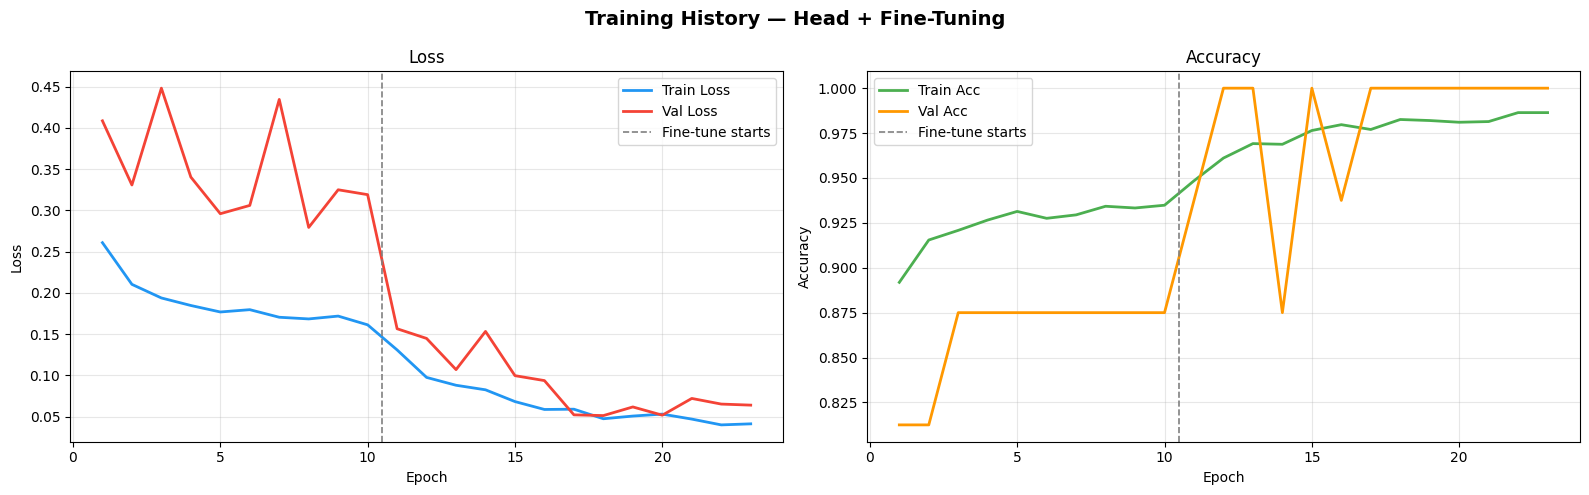

Training curves saved.


In [14]:
# ──────────────────────────────────────────────────────────────
# STEP 11 — PLOT TRAINING CURVES
# ──────────────────────────────────────────────────────────────

# Combine both training phases into unified curves
all_train_losses = head_train_losses + fine_train_losses
all_val_losses   = head_val_losses   + fine_val_losses
all_train_accs   = head_train_accs   + fine_train_accs
all_val_accs     = head_val_accs     + fine_val_accs

epochs_total = list(range(1, len(all_train_losses) + 1))
phase_split  = len(head_train_losses)             # vertical line position

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Training History — Head + Fine-Tuning", fontsize=14, fontweight="bold")

# ---- Loss curve ----
ax = axes[0]
ax.plot(epochs_total, all_train_losses, label="Train Loss", color="#2196F3", linewidth=2)
ax.plot(epochs_total, all_val_losses,   label="Val Loss",   color="#F44336", linewidth=2)
ax.axvline(x=phase_split + 0.5, color="gray", linestyle="--", linewidth=1.2,
           label="Fine-tune starts")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Loss")
ax.legend()
ax.grid(alpha=0.3)

# ---- Accuracy curve ----
ax = axes[1]
ax.plot(epochs_total, all_train_accs, label="Train Acc", color="#4CAF50", linewidth=2)
ax.plot(epochs_total, all_val_accs,   label="Val Acc",   color="#FF9800", linewidth=2)
ax.axvline(x=phase_split + 0.5, color="gray", linestyle="--", linewidth=1.2,
           label="Fine-tune starts")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print("Training curves saved.")


In [15]:

# Load the best saved weights
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.eval()

all_preds  = []
all_labels = []
test_loss  = 0.0
test_correct = 0
test_total   = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        outputs = model(images)
        loss    = criterion(outputs, labels)

        test_loss    += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        test_correct += (preds == labels).sum().item()
        test_total   += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_loss = test_loss    / test_total
test_acc  = test_correct / test_total

print("\n" + "="*50)
print(f"  TEST RESULTS")
print(f"  Loss     : {test_loss:.4f}")
print(f"  Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print("="*50)



  TEST RESULTS
  Loss     : 0.3061
  Accuracy : 0.9183  (91.83%)



Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.96      0.82      0.88       234
   PNEUMONIA       0.90      0.98      0.94       390

    accuracy                           0.92       624
   macro avg       0.93      0.90      0.91       624
weighted avg       0.92      0.92      0.92       624



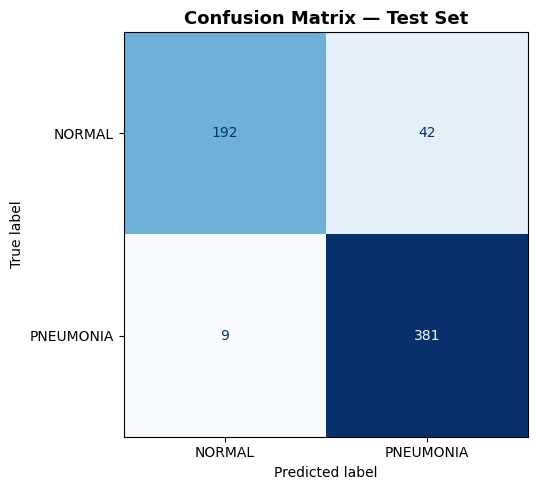

Confusion matrix saved.


In [16]:
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=Class_Names))

# ---- Confusion matrix ----
cm_array = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_array, display_labels=Class_Names)
disp.plot(cmap="Blues", ax=ax, colorbar=False)
ax.set_title("Confusion Matrix — Test Set", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()
print("Confusion matrix saved.")


/tmp/ipykernel_4557/3866347490.py:34: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  img_display = img_t * torch.tensor(INV_STD)[:, None, None] + torch.tensor(INV_MEAN)[:, None, None]


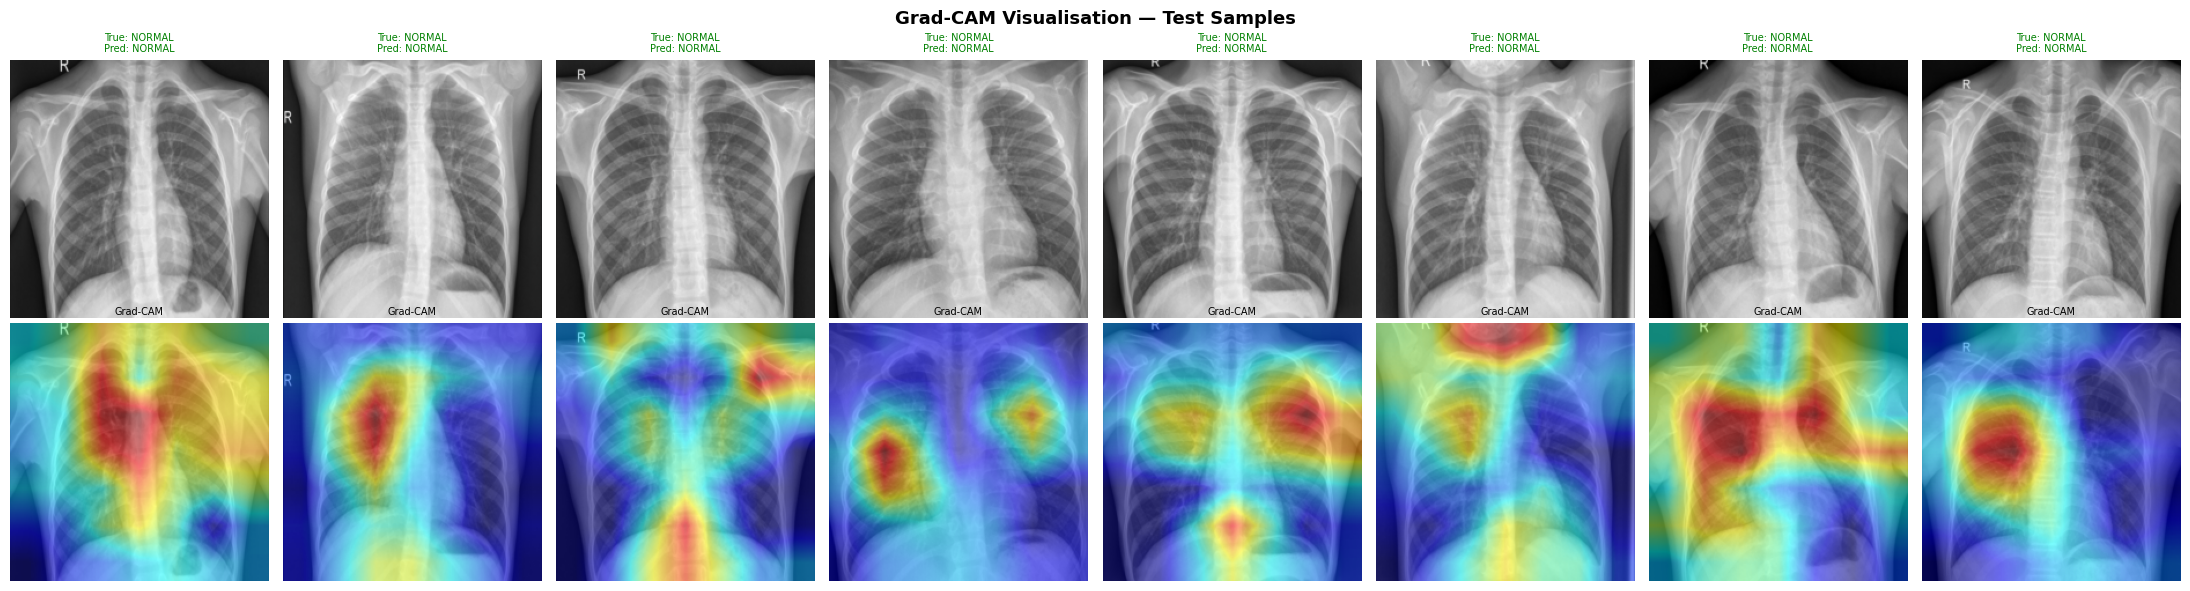

Grad-CAM visualization saved.


In [17]:
# ──────────────────────────────────────────────────────────────
# STEP 14 — GRAD-CAM VISUALISATION
# ──────────────────────────────────────────────────────────────
# Grad-CAM shows WHICH regions of the X-ray the model focuses on.
# We target the last convolutional block of EfficientNet-B0.

# Target layer = last conv block before the global avg-pool
target_layer = model.features[-1]          # block 8 / last MBConv block

cam = GradCAM(model=model, target_layers=[target_layer])

# Grab 8 test images for Grad-CAM
sample_imgs_gc, sample_lbs_gc = next(iter(test_loader))
sample_imgs_gc = sample_imgs_gc[:8].to(device)
sample_lbs_gc  = sample_lbs_gc[:8]

# Build the ClassifierOutputTarget list (use predicted class for each image)
model.eval()
with torch.no_grad():
    raw_preds = model(sample_imgs_gc).argmax(dim=1).cpu().numpy()

targets = [ClassifierOutputTarget(int(c)) for c in raw_preds]

# Generate Grad-CAM masks
grayscale_cams = cam(input_tensor=sample_imgs_gc, targets=targets)

# ---- Plot original + Grad-CAM overlay ----
fig, axes = plt.subplots(2, 8, figsize=(22, 6))
fig.suptitle("Grad-CAM Visualisation — Test Samples", fontsize=13, fontweight="bold")

for idx in range(8):
    # Un-normalise image for display
    img_t = sample_imgs_gc[idx].cpu()
    img_display = img_t * torch.tensor(INV_STD)[:, None, None] + torch.tensor(INV_MEAN)[:, None, None]
    img_display = img_display.permute(1, 2, 0).clamp(0, 1).numpy()

    # Original image
    axes[0][idx].imshow(img_display, cmap="gray")
    pred_name  = Class_Names[raw_preds[idx]]
    true_name  = Class_Names[sample_lbs_gc[idx].item()]
    color      = "green" if pred_name == true_name else "red"
    axes[0][idx].set_title(f"True: {true_name}\nPred: {pred_name}",
                            fontsize=7, color=color)
    axes[0][idx].axis("off")

    # Grad-CAM overlay
    cam_overlay = show_cam_on_image(img_display, grayscale_cams[idx], use_rgb=True)
    axes[1][idx].imshow(cam_overlay)
    axes[1][idx].set_title("Grad-CAM", fontsize=7)
    axes[1][idx].axis("off")

plt.tight_layout()
plt.savefig("gradcam_visualization.png", dpi=120, bbox_inches="tight")
plt.show()
print("Grad-CAM visualization saved.")



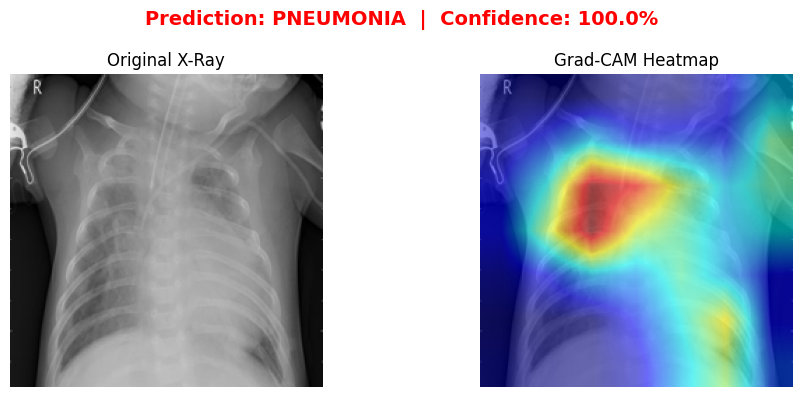


────────────────────────────────────────
  SINGLE IMAGE PREDICTION
────────────────────────────────────────
  NORMAL       [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]    0.0%
  PNEUMONIA    [██████████████████████████████]  100.0%
────────────────────────────────────────
  → PREDICTION : PNEUMONIA  (100.0% confident)
────────────────────────────────────────

✅ All done! Files saved:
   best_model.pth          — best model weights
   sample_images.png       — training sample grid
   training_curves.png     — loss & accuracy curves
   confusion_matrix.png    — confusion matrix
   gradcam_visualization.png — Grad-CAM on test batch
   single_prediction.png   — single image inference


In [18]:

IMAGE_PATH = "chest_xray/test/PNEUMONIA/person1_virus_6.jpeg"   # <- EDIT THIS

# ---- Load & preprocess the single image ----
raw_image = Image.open(IMAGE_PATH).convert("RGB")

preprocess = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])
input_tensor = preprocess(raw_image).unsqueeze(0).to(device)   # shape: [1, 3, 224, 224]

# ---- Inference ----
model.eval()
with torch.no_grad():
    logits      = model(input_tensor)                           # raw scores
    probs       = torch.softmax(logits, dim=1)[0]              # probabilities
    pred_class  = probs.argmax().item()
    pred_label  = Class_Names[pred_class]
    confidence  = probs[pred_class].item() * 100

# ---- Grad-CAM for the single prediction ----
cam_single     = GradCAM(model=model, target_layers=[target_layer])
cam_mask_single = cam_single(
    input_tensor=input_tensor,
    targets=[ClassifierOutputTarget(pred_class)],
)[0]

img_np = np.array(raw_image.resize((IMG_SIZE, IMG_SIZE))) / 255.0
cam_overlay_single = show_cam_on_image(img_np.astype(np.float32), cam_mask_single, use_rgb=True)

# ---- Display prediction ----
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle(
    f"Prediction: {pred_label}  |  Confidence: {confidence:.1f}%",
    fontsize=14, fontweight="bold",
    color="red" if pred_label == "PNEUMONIA" else "green",
)

axes[0].imshow(raw_image.resize((IMG_SIZE, IMG_SIZE)), cmap="gray")
axes[0].set_title("Original X-Ray")
axes[0].axis("off")

axes[1].imshow(cam_overlay_single)
axes[1].set_title("Grad-CAM Heatmap")
axes[1].axis("off")

plt.tight_layout()
plt.savefig("single_prediction.png", dpi=120, bbox_inches="tight")
plt.show()

# ---- Print probability breakdown ----
print("\n" + "─"*40)
print("  SINGLE IMAGE PREDICTION")
print("─"*40)
for i, cls in enumerate(Class_Names):
    bar_len = int(probs[i].item() * 30)
    bar     = "█" * bar_len + "░" * (30 - bar_len)
    print(f"  {cls:<12} [{bar}]  {probs[i].item()*100:5.1f}%")
print("─"*40)
print(f"  → PREDICTION : {pred_label}  ({confidence:.1f}% confident)")
print("─"*40)

print("\n✅ All done! Files saved:")
print("   best_model.pth          — best model weights")
print("   sample_images.png       — training sample grid")
print("   training_curves.png     — loss & accuracy curves")
print("   confusion_matrix.png    — confusion matrix")
print("   gradcam_visualization.png — Grad-CAM on test batch")
print("   single_prediction.png   — single image inference")

In [20]:
# ──────────────────────────────────────────────────────────────
# DEPLOYMENT — Gradio Web App (runs directly in Colab)
# ──────────────────────────────────────────────────────────────

!pip install gradio -q

import gradio as gr
import torch
import torch.nn as nn
from torchvision import transforms, models
from PIL import Image
import numpy as np

# ---- Reload model ----
deploy_model = models.efficientnet_b0(weights=None)
deploy_model.classifier = nn.Sequential(
    nn.Dropout(p=0.4, inplace=True),
    nn.Linear(deploy_model.classifier[1].in_features, 256),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(256, 2),
)
deploy_model.load_state_dict(torch.load("best_model.pth", map_location="cpu"))
deploy_model.eval()

CLASS_NAMES = ["NORMAL", "PNEUMONIA"]

# ---- Preprocessing ----
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# ---- Prediction function ----
def predict(image):
    img = Image.fromarray(image).convert("RGB")
    tensor = preprocess(img).unsqueeze(0)

    with torch.no_grad():
        probs = torch.softmax(deploy_model(tensor), dim=1)[0]

    return {CLASS_NAMES[i]: float(probs[i]) for i in range(2)}

# ---- Launch App ----
app = gr.Interface(
    fn=predict,
    inputs=gr.Image(label="Upload Chest X-Ray"),
    outputs=gr.Label(label="Diagnosis", num_top_classes=2),
    title="🫁 Chest X-Ray Pneumonia Detector",
    description="Upload a chest X-ray image to detect Pneumonia.",
    examples=[],
    theme=gr.themes.Soft(),
)

app.launch(share=True)   # share=True → يديك public link

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f7760cd3297c61c004.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
